# VulnScope model evaluation and error analysis

This notebook evaluates the CVE-only severity-prioritization model on the untouched 2025 temporal test period. The target is **severe CVE = CVSS base score >= 7.0 (High or Critical)**. The score is not an exploitation probability.

In [1]:
from pathlib import Path
import json
import re
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'processed' / 'cves_clean.parquet'
MODEL_PATH = ROOT / 'artifacts' / 'cve_priority_model.joblib'
METADATA_PATH = ROOT / 'artifacts' / 'cve_priority_model_metadata.json'
REPORT_DIR = ROOT / 'reports' / 'cve_priority_model'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
model = joblib.load(MODEL_PATH)
metadata = json.loads(METADATA_PATH.read_text())
metadata['label_definition'], metadata['model_version']

('Severe CVE: CVSS base score >= 7.0 (High or Critical)',
 'cve_priority_tfidf_svm_v3')

## Reconstruct the 2025 test set

Only `title` and `description` are passed to the model. CVSS fields are used after prediction solely to construct the evaluation label.

In [2]:
columns = ['cve_id', 'publication_year', 'date_published', 'title', 'description', 'cvss_score', 'cvss_version', 'severity', 'primary_vendor', 'primary_cwe', 'cna']
test = pd.read_parquet(DATA_PATH, columns=columns)
test = test[(test.publication_year == 2025) & test.cvss_score.notna()].copy()
test['model_text'] = (test.title.fillna('') + ' ' + test.description.fillna('')).str.strip()
test['actual_severe'] = (test.cvss_score >= metadata['cvss_priority_cutoff']).astype(int)
test['priority_probability'] = model.predict_proba(test.model_text)[:, 1]
test['predicted_severe'] = (test.priority_probability >= metadata['selected_threshold']).astype(int)
test.shape, test.actual_severe.mean(), metadata['selected_threshold']

((45198, 15), 0.4397539714146644, 0.35243500904515856)

## Metrics and honest baselines

In [3]:
def metric_row(name, probability, prediction):
    return {
        'model': name,
        'precision': precision_score(test.actual_severe, prediction, zero_division=0),
        'recall': recall_score(test.actual_severe, prediction, zero_division=0),
        'f1': f1_score(test.actual_severe, prediction, zero_division=0),
        'pr_auc': average_precision_score(test.actual_severe, probability),
        'brier': brier_score_loss(test.actual_severe, probability),
    }

prevalence = test.actual_severe.mean()
majority_probability = np.full(len(test), prevalence)
majority_prediction = np.zeros(len(test), dtype=int)
keyword_pattern = r'(?i)remote code execution|arbitrary code|authentication bypass|privilege escalation|command injection'
keyword_prediction = test.model_text.str.contains(keyword_pattern, regex=True).astype(int).to_numpy()
keyword_probability = keyword_prediction.astype(float)
comparison = pd.DataFrame([
    metric_row('prevalence baseline', majority_probability, majority_prediction),
    metric_row('keyword baseline', keyword_probability, keyword_prediction),
    metric_row('VulnScope TF-IDF SVM', test.priority_probability.to_numpy(), test.predicted_severe.to_numpy()),
])
comparison.to_csv(REPORT_DIR / 'baseline_comparison.csv', index=False)
comparison

,model,precision,recall,f1,pr_auc,brier
0,prevalence baseline,0.000000,0.000000,0.000000,0.439754,0.246370
1,keyword baseline,0.793041,0.244264,0.373490,0.526050,0.360370
2,VulnScope TF-IDF SVM,0.632693,0.804840,0.708459,0.764234,0.177665


## Coverage versus efficiency

Following the practitioner-oriented terminology used by EPSS, **coverage = recall** and **efficiency = precision**. This curve evaluates our severe-CVE target; it must not be interpreted as exploitation coverage.

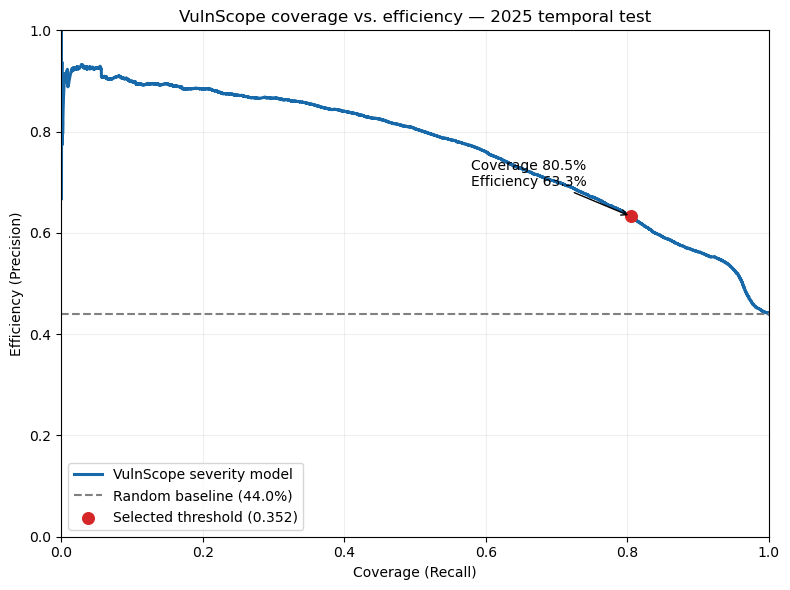

In [4]:
efficiency, coverage, curve_thresholds = precision_recall_curve(test.actual_severe, test.priority_probability)
selected_efficiency = precision_score(test.actual_severe, test.predicted_severe)
selected_coverage = recall_score(test.actual_severe, test.predicted_severe)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(coverage, efficiency, color='#1769aa', linewidth=2.2, label='VulnScope severity model')
ax.axhline(prevalence, color='gray', linestyle='--', label=f'Random baseline ({prevalence:.1%})')
ax.scatter([selected_coverage], [selected_efficiency], color='#d62728', s=70, zorder=3, label=f'Selected threshold ({metadata["selected_threshold"]:.3f})')
ax.annotate(f'Coverage {selected_coverage:.1%}\nEfficiency {selected_efficiency:.1%}', (selected_coverage, selected_efficiency), xytext=(-115, 22), textcoords='offset points', arrowprops={'arrowstyle': '->'})
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='Coverage (Recall)', ylabel='Efficiency (Precision)', title='VulnScope coverage vs. efficiency — 2025 temporal test')
ax.grid(alpha=0.2)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(REPORT_DIR / 'coverage_vs_efficiency.png', dpi=180, bbox_inches='tight')
pd.DataFrame({'coverage': coverage[:-1], 'efficiency': efficiency[:-1], 'threshold': curve_thresholds}).to_csv(REPORT_DIR / 'coverage_vs_efficiency.csv', index=False)
plt.show()

## Leakage-language audit

In [5]:
leakage_patterns = {
    'explicit_cvss_score': r'(?i)CVSS(?:v[234](?:\.\d)?)?[^.\n]{0,30}(?:score|base)[^0-9]{0,10}(?:[0-9](?:\.[0-9])?|10(?:\.0)?)',
    'severity_word': r'(?i)\b(?:critical|high severity|severity: high|severity: critical)\b',
    'cvss_vector': r'CVSS:[234]\.[01]/',
}
leakage_audit = pd.DataFrame([
    {'indicator': name, 'rows': int(test.model_text.str.contains(pattern, regex=True).sum()), 'share': float(test.model_text.str.contains(pattern, regex=True).mean())}
    for name, pattern in leakage_patterns.items()
])
leakage_audit.to_csv(REPORT_DIR / 'text_leakage_audit.csv', index=False)
leakage_audit

,indicator,rows,share
0,explicit_cvss_score,9,0.000199
1,severity_word,3353,0.074185
2,cvss_vector,334,0.007390


## Confusion matrix and error samples

In [6]:
matrix = confusion_matrix(test.actual_severe, test.predicted_severe)
pd.DataFrame(matrix, index=['actual_not_severe', 'actual_severe'], columns=['predicted_not_severe', 'predicted_severe'])

,predicted_not_severe,predicted_severe
actual_not_severe,16035,9287
actual_severe,3879,15997


In [7]:
error_columns = ['cve_id', 'date_published', 'primary_vendor', 'primary_cwe', 'cvss_score', 'priority_probability', 'title', 'description']
false_positives = test[(test.actual_severe == 0) & (test.predicted_severe == 1)].sort_values('priority_probability', ascending=False)
false_negatives = test[(test.actual_severe == 1) & (test.predicted_severe == 0)].sort_values('priority_probability')
false_positives[error_columns].head(100).to_csv(REPORT_DIR / 'false_positives_top100.csv', index=False)
false_negatives[error_columns].head(100).to_csv(REPORT_DIR / 'false_negatives_top100.csv', index=False)
{'false_positives': len(false_positives), 'false_negatives': len(false_negatives)}

{'false_positives': 9287, 'false_negatives': 3879}

## Performance by reporting group

In [8]:
def group_metrics(frame, field, minimum_rows=100):
    rows = []
    for value, group in frame.fillna({field: 'MISSING'}).groupby(field):
        if len(group) < minimum_rows or group.actual_severe.nunique() < 2:
            continue
        rows.append({
            field: value, 'rows': len(group), 'prevalence': group.actual_severe.mean(),
            'precision': precision_score(group.actual_severe, group.predicted_severe, zero_division=0),
            'recall': recall_score(group.actual_severe, group.predicted_severe, zero_division=0),
            'f1': f1_score(group.actual_severe, group.predicted_severe, zero_division=0),
            'pr_auc': average_precision_score(group.actual_severe, group.priority_probability),
        })
    return pd.DataFrame(rows).sort_values(['rows', 'f1'], ascending=[False, False])

for field in ['primary_vendor', 'primary_cwe', 'cna', 'cvss_version']:
    result = group_metrics(test, field)
    result.to_csv(REPORT_DIR / f'performance_by_{field}.csv', index=False)

group_metrics(test, 'primary_vendor').head(15)

,primary_vendor,rows,prevalence,precision,recall,f1,pr_auc
17,MISSING,5974,0.459826,0.607971,0.916272,0.730942,0.675293
16,Linux,2721,0.700110,0.822372,0.702362,0.757644,0.858494
20,Microsoft,1254,0.736045,0.844081,0.950163,0.893986,0.953122
0,Adobe,829,0.361882,0.916107,0.910000,0.913043,0.979991
2,Apple,727,0.392022,0.502273,0.775439,0.609655,0.589033
12,IBM,606,0.217822,0.622222,0.848485,0.717949,0.831382
9,Google,577,0.606586,0.711297,0.971429,0.821256,0.891526
25,PHPGurukul,505,0.009901,0.131579,1.000000,0.232558,1.000000
32,SourceCodester,355,0.002817,0.012987,1.000000,0.025641,1.000000
24,Oracle Corporation,313,0.220447,0.773810,0.942029,0.849673,0.953134


## Sensitivity check without explicit severity language

This does not retrain the model; it checks whether the reported result collapses after excluding test records containing explicit CVSS scores, vectors, or severity words.

In [9]:
explicit_language = pd.Series(False, index=test.index)
for pattern in leakage_patterns.values():
    explicit_language |= test.model_text.str.contains(pattern, regex=True)
sensitivity = test.loc[~explicit_language].copy()
sensitivity_metrics = pd.DataFrame([{
    'rows': len(sensitivity),
    'prevalence': sensitivity.actual_severe.mean(),
    'precision': precision_score(sensitivity.actual_severe, sensitivity.predicted_severe),
    'recall': recall_score(sensitivity.actual_severe, sensitivity.predicted_severe),
    'f1': f1_score(sensitivity.actual_severe, sensitivity.predicted_severe),
    'pr_auc': average_precision_score(sensitivity.actual_severe, sensitivity.priority_probability),
    'brier': brier_score_loss(sensitivity.actual_severe, sensitivity.priority_probability),
}])
sensitivity_metrics.to_csv(REPORT_DIR / 'leakage_sensitivity.csv', index=False)
sensitivity_metrics

,rows,prevalence,precision,recall,f1,pr_auc,brier
0,41577,0.455949,0.632923,0.810677,0.710856,0.767441,0.18207


## Interpretation

The temporal test measures prediction of a High-or-Critical CVSS profile, not exploitation. Review the exported errors and leakage-language counts before using the model in the agent. The current source is a latest-state CVE snapshot; reconstructing publication-time text from Git history remains the strongest next validation improvement.